# Práctica 1: Regresión Lineal Simple

## 1. Cargar datos y librerías

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("autos2.csv")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


## 2. Definir variables predictoras y variable objetivo

In [12]:
X = df[['city-mpg']]
y = df['price']

## 3. Dividir en conjunto de entrenamiento y prueba

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4. Entrenar modelo de regresión lineal simple

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## 5. Evaluar el modelo

In [15]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

Error cuadrático medio (MSE): 74223480.07
Coeficiente de determinación (R²): 0.39


In [16]:
rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 8615.30


## 6. Coeficientes del modelo

In [17]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
})

print(coef_df)
print(f"Intersección (bias): {model.intercept_:.2f}")

   Variable  Coeficiente
0  city-mpg  -742.942492
Intersección (bias): 31365.48


### Interpretación

El modelo obtuvo un RMSE de **8,615.30**, lo que indica que las predicciones del precio pueden presentar una diferencia considerable respecto a los valores reales.

El valor de **R² = 0.39** indica que la variable `city-mpg` permite explicar aproximadamente el **39% de la variación del precio** de los automóviles. Por lo tanto, utilizar únicamente esta variable no es suficiente para realizar predicciones precisas.

El coeficiente de `city-mpg` es **-742.94**, lo que muestra una relación negativa entre el rendimiento de combustible en ciudad y el precio estimado por el modelo.

## 7. Comparar precios reales vs. predichos

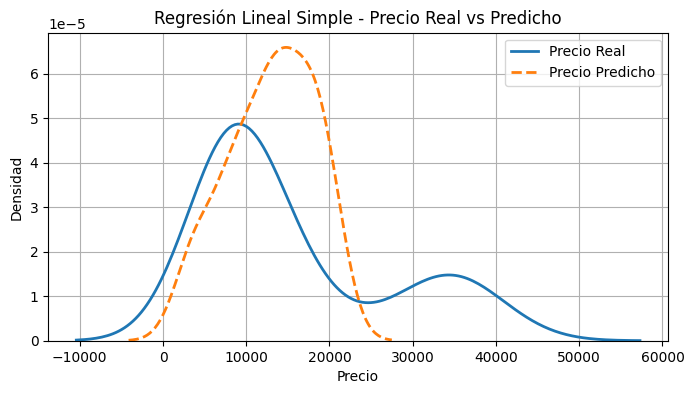

In [18]:
plt.figure(figsize=(8, 4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')

plt.xlabel("Precio")
plt.ylabel("Densidad")
plt.title("Regresión Lineal Simple - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

### Puntos clave del gráfico

La distribución de los precios predichos presenta diferencias respecto a la distribución de los precios reales. El modelo concentra sus predicciones principalmente en valores intermedios y tiene dificultades para representar los vehículos con precios más altos.

Esto concuerda con el valor de **R² = 0.39**, ya que una sola variable no logra representar completamente las diferencias existentes en los precios.

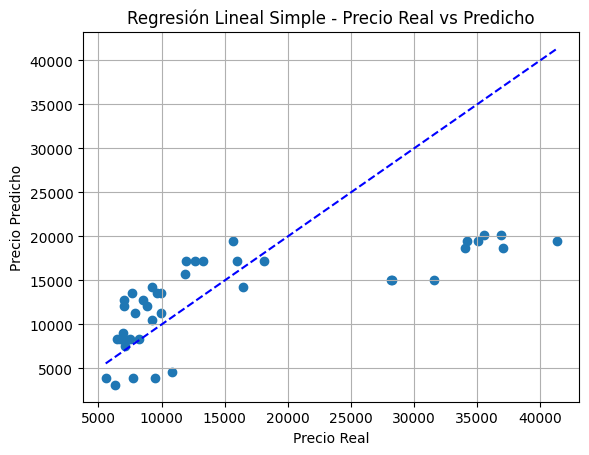

In [19]:
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'b--'
)

plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresión Lineal Simple - Precio Real vs Predicho")
plt.grid(True)
plt.show()

### Interpretación

Los puntos más cercanos a la línea representan predicciones con menor diferencia respecto al precio real. Sin embargo, se observa una separación considerable en varios casos.

En los vehículos de mayor precio, el modelo tiende a predecir valores inferiores a los reales. Esto confirma que utilizar únicamente `city-mpg` como variable predictora limita la precisión del modelo.